<!-- Esto es para justificar texto a la derecha -->



# Preliminares

En este documento ajustaremos algunos modelos de regresión lineal a los datos sobre venta de vinos. Para ello, utilizamos el conjunto de datos que generamos tras la depuración, asegurando un conjunto de datos "limpios" y exentos de ciertos peligros.

En primer lugar leemos el archivo generado en la depuración. Destacar que aquí se podría "repetir" el proceso con distintas posibilidades de tratamiento previo de las variables. Tal vez probar con winsorize e imputaciones aleatorias y luego comparar con otro esquema como el de eliminación de outliers y missing o con conversión de outliers a missings e imputación por modelos multivariantes...Todo un mundo de posibilidades!!


In [91]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)


Mounted at /content/drive


In [92]:

#Acceso a carpeta y carga del archivo de funciones
import sys
sys.path.append('/content/drive/MyDrive/Material Minería de Datos 2025_26_Online')

# Cargo funciones por ruta absoluta
#from NuestrasFunciones import *
execfile('/content/drive/MyDrive/Material Minería de Datos 2025_26_Online/NuestrasFunciones.py')

In [93]:
# Graphic option. You may need it to show inline plots...
#import plotly.io as pio
#pio.renderers.default='notebook'
!pip install ydata-profiling
#!pip install optbinning
#!pip install relativeImp
!python -V

Python 3.12.12


In [94]:
#%matplotlib inline+
# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')


In [95]:
import pandas as pd
import numpy as np

# Leer datos depurados datosvinoDep
#vinosDep = pd.read_csv(r'C:\Users\Guille\Documents\MineriaDatos_2022_23_Online\Material Minería de Datos_Febrero_2023\Datos\DatosVino.csv', index_col=0)
vinosDep = pd.read_hdf(r'/content/drive/MyDrive/Material Minería de Datos 2025_26_Online/PARTE I_Depuracion y Regresiones/Dia1_MDDepuracion/DatosVinoDep_winsRand.h5','df')

# Descriptivo de comprobación
vinosDep.head()


,ID,Acidez,AcidoCitrico,Azucar,CloruroSodico,Densidad,pH,Sulfatos,Alcohol,CalifProductor,PrecioBotella,Etiqueta,Clasificacion,Region,n_missings,Beneficio,Compra
0,2,0.16,-0.81,26.10,-0.425,1.02792,3.38,0.70,16.2,2,1.00,M,***,Reg 1,1,515,1
1,4,2.64,-0.88,14.80,0.037,0.99518,3.12,0.48,22.0,3,3.38,M,***,Reg 3,0,585,1
2,8,0.29,-0.40,21.50,0.060,0.99572,3.49,1.21,10.3,3,3.72,R,Desc,Reg 1,0,0,0
3,11,-1.22,0.34,1.40,0.040,1.03236,3.20,0.09,11.6,2,6.23,B,***,Reg 2,1,775,1
4,12,0.27,1.05,11.25,-0.007,0.99620,4.93,0.26,15.0,1,2.44,R,Desc,Reg 2,0,596,1


Solicitamos información sobre el tipo de variables del archivo a modo de comprobación y observamos que se han cambiado los tipos! Esto se produce en el proceso de escritura y lectura del csv... Habrá que cambiarlo.



In [96]:
vinosDep.info()



<class 'pandas.core.frame.DataFrame'>
Index: 6365 entries, 0 to 6364
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   ID              6365 non-null   int64   
 1   Acidez          6365 non-null   float64 
 2   AcidoCitrico    6365 non-null   float64 
 3   Azucar          6365 non-null   float64 
 4   CloruroSodico   6365 non-null   float64 
 5   Densidad        6365 non-null   float64 
 6   pH              6365 non-null   float64 
 7   Sulfatos        6365 non-null   float64 
 8   Alcohol         6365 non-null   float64 
 9   CalifProductor  6365 non-null   int64   
 10  PrecioBotella   6365 non-null   float64 
 11  Etiqueta        6365 non-null   category
 12  Clasificacion   6365 non-null   category
 13  Region          6365 non-null   category
 14  n_missings      6365 non-null   int64   
 15  Beneficio       6365 non-null   int64   
 16  Compra          6365 non-null   category
dtypes: category(4), flo

Si leemos el archivo desde csv tendremos que volver a cambiar los tipos de variables puesto que se pierden por el camino.


In [97]:
vinosDep.Clasificacion.value_counts(sort=False)

,count
Clasificacion,
*,1535
**,1754
***,1074
****,322
Desc,1680


In [98]:
# Lista de columnas con menos de 10 valores distintos. Potenciales factores!
#to_factor = list(vinosDep.loc[:,vinosDep.nunique() <= 10]);

# Podemos cambiar el tipo de todas ellas a factor de una vez
#vinosDep[to_factor] = vinosDep[to_factor].astype('category')

# Ordenamos categorías de los fatcores de interés
#vinosDep["Etiqueta"] = vinosDep["Etiqueta"].cat.reorder_categories(['MM','M','R','B','MB'])
vinosDep["Clasificacion"] = vinosDep["Clasificacion"].cat.reorder_categories(['Desc','*','**','***','****'])


Echamos un vistazo a las distribuciones de las variables para asegurar. Primero continuas y luego categóricas.



In [99]:
# Descripción de los datos
vinosDep.describe().T


,count,mean,std,min,25%,50%,75%,max
ID,6365.0,8010.702278,4654.939139,2.00000,3980.000000,8065.0000,12027.0000,16128.0000
Acidez,6365.0,0.331342,0.769865,-2.05000,0.130000,0.2800,0.6500,2.7300
AcidoCitrico,6365.0,0.315038,0.842346,-2.27000,0.020000,0.3100,0.5800,2.9000
Azucar,6365.0,5.725334,33.487854,-97.80000,-1.400000,4.1000,15.9000,109.9000
CloruroSodico,6365.0,0.051394,0.316620,-0.92300,-0.032000,0.0460,0.1480,1.0270
Densidad,6365.0,0.994214,0.025679,0.91473,0.988245,0.9944,1.0006,1.0739
pH,6365.0,3.202669,0.664795,1.16000,2.960000,3.1900,3.4600,5.2600
Sulfatos,6365.0,0.524105,0.926466,-2.32000,0.270000,0.5000,0.8800,3.3800
Alcohol,6365.0,10.629207,3.512192,0.00000,9.000000,10.4000,12.4000,22.7000
CalifProductor,6365.0,2.760094,1.310444,0.00000,2.000000,3.0000,3.0000,10.0000


In [100]:
# Descripción de los datos
vinosDep.describe(exclude=np.number).T


,count,unique,top,freq
Etiqueta,6365,5,R,2800
Clasificacion,6365,5,**,1754
Region,6365,3,Reg 3,2169
Compra,6365,2,1,4998


Parece que todo es correcto.


# Estudio descriptivo de relaciones con la respuesta

En este apartado intentaremos descubrir a priori las relaciones marginales de las variables con la variable objetivo para hacernos una idea de cuales de ellas serán potencialmente influyentes en los modelos de regresión que ajustemos.


In [32]:
import plotly.express as px
#px.scatter_matrix(vinosDep)

import seaborn as sns
# Matriz de scatterplots
sns.pairplot(vinosDep.drop(columns=['ID','n_missings']),corner=True)

Output hidden; open in https://colab.research.google.com to view.

Podemos generar este tipo de gráficos de rejilla, donde se pueden visualizar las relaciones a pares de todas las variables del archivo. En este caso, dado el carácter de los gráficos, solo será de aplicación a variables de tipo numérico.

No tiene muy buena pinta ya que las variables no parecen generar un patrón especial frente a la varuiable objetivo...se intuye poco valor predictivo de las variables para la regresión lineal.

Por otro lado, llama la atención la gran cantidad de 0 que tiene la variable objetivo continua Beneficio...Distribución muy compleja de modelizar..Tal vez habría que replantear el análisis y generar un modelo de regresión lineal para estimar el beneficio de los vinos que presentan algún beneficio.. Teniendo así una distribución de la variable respuesta más llevadera.

En este punto, podríamos pensar en una doble vía de actuación para el modelo predictivo final que generemos. Por una parte, un modelo de clasificación previa que estime la probabilidad de ser un vino con Compra = 1 (todo vino que tiene beneficio \> 0) y posteriormente, para los clasificados como 1 en compra, un modelo de regresión lineal que estime el beneficio esperado. De alguna forma, estamos planteando un **ensamble** de modelos. Solo por plantear alternativas.


# Variables de control

No es mala idea generar un par de variables de "control" para la evaluación de los efectos de los predictores frente a la respuesta. La idea es la siguiente: si generamos variables en el más estricto sentido aleatorio (por ejemplo siguiendo una distribución uniforme[0,1]) cualquier relación que estas presenten con la variable respuesta serán debidas puramente al azar, con lo que se pueden considerar relaciones espurias, es decir, falsas.

Por tanto, ya sea en la inspección preliminar de relaciones con la respuesta mediante correlación (relación lineal, válido para continua-continua) o VCramer (asociación en tablas de contingencia, válido para cruce de variables categóricas/nominales o continuas tramificadas) o bien en los propios modelos de regresión, las variables que presenten una menor relación con la respuesta que las variables de control, tendrán una sombra de sospecha sobre la veracidad de esa relación y probablemente serán descartadas, al menos en su estado original (siempre se pueden tratar de transformar, tramificar etc)

In [101]:
vinosDep['aleatorio'] = np.random.uniform(0,1,size=vinosDep.shape[0])
vinosDep['aleatorio2'] = np.random.uniform(0,1,size=vinosDep.shape[0])
vinosDep.head()


,ID,Acidez,AcidoCitrico,Azucar,CloruroSodico,Densidad,pH,Sulfatos,Alcohol,CalifProductor,PrecioBotella,Etiqueta,Clasificacion,Region,n_missings,Beneficio,Compra,aleatorio,aleatorio2
0,2,0.16,-0.81,26.10,-0.425,1.02792,3.38,0.70,16.2,2,1.00,M,***,Reg 1,1,515,1,0.322650,0.662518
1,4,2.64,-0.88,14.80,0.037,0.99518,3.12,0.48,22.0,3,3.38,M,***,Reg 3,0,585,1,0.553591,0.810484
2,8,0.29,-0.40,21.50,0.060,0.99572,3.49,1.21,10.3,3,3.72,R,Desc,Reg 1,0,0,0,0.259819,0.456593
3,11,-1.22,0.34,1.40,0.040,1.03236,3.20,0.09,11.6,2,6.23,B,***,Reg 2,1,775,1,0.523893,0.060259
4,12,0.27,1.05,11.25,-0.007,0.99620,4.93,0.26,15.0,1,2.44,R,Desc,Reg 2,0,596,1,0.436770,0.640369


## (Opcional) Interesante función para obtener un reporte descriptivo del archivo completo

Evalúa a nivel univariante y bivariante las variables presentes en el archivo. También da información sobre valores extremos y missings, por lo que la podríamos utilizar en nuestra etapa de depuración de los datos.


In [34]:
#!pip install ydata-profiling
import ydata_profiling
ydata_profiling.ProfileReport(vinosDep)


Output hidden; open in https://colab.research.google.com to view.

Muchísima información disponible en este reporte automático. A nivel univariante podemos comprobar distribuciones de variables continuas y representatividad de las categorías de los factores. A nivel bivariado, se evalúan las relaciones a pares de distintas formas. Especialmente interesante el gráfico de correlación *Auto* por su filosofía. Genera la correlación de spearman para continua-continua y v de cramer para categórica-categórica y para continua-categórica previamente tramificada la primera. Va muy en nuestra línea de pensamiento.

Con ese 21% de valores nulos, vamos a decidir partir el archivo para considerar solamente los vinos de Compra = 1 y ajustaremos el modelo de regresión sobre esta submuestra. Es importante que estas decisiones sean consensuadas y se especifiquen claramente en el informe de análisis, trasladándose a la fase de interpretación de resultados.

Creamos el archivo **vinosCompra** a este efecto.


In [103]:
vinosCompra = vinosDep.loc[vinosDep.Compra == 1].drop(['Compra'],axis=1).reset_index(drop=True)
vinosCompra.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   ID              4998 non-null   int64   
 1   Acidez          4998 non-null   float64 
 2   AcidoCitrico    4998 non-null   float64 
 3   Azucar          4998 non-null   float64 
 4   CloruroSodico   4998 non-null   float64 
 5   Densidad        4998 non-null   float64 
 6   pH              4998 non-null   float64 
 7   Sulfatos        4998 non-null   float64 
 8   Alcohol         4998 non-null   float64 
 9   CalifProductor  4998 non-null   int64   
 10  PrecioBotella   4998 non-null   float64 
 11  Etiqueta        4998 non-null   category
 12  Clasificacion   4998 non-null   category
 13  Region          4998 non-null   category
 14  n_missings      4998 non-null   int64   
 15  Beneficio       4998 non-null   int64   
 16  aleatorio       4998 non-null   float64 
 17  aleatorio2    

In [36]:
#ydata_profiling.ProfileReport(vinosCompra)



En el reporte para el nuevo archivo, volvemos a tener alta correlación (en un sentido amplio) de las variables Etiqueta y Clasificación con la variable objetivo, apareciendo algo coloreada la variable Alcohol. Pocas relaciones destacables a parte de esto.

Ya que vamos a hacer cosas como evaluación de las relaciones entre los predictores y la respuesta o creación masiva de transformaciones para conseguir linealidad, lo mejor es separar las respuestas y quedarnos con el input depurado, de esta forma podemos aplicar una misma función a todo el conjunto sin peligro de transformar las respuestas y cosas raras que puedan suceder.


In [104]:
# Eliminar variable objetivo continua
varObjCont = vinosCompra.Beneficio
imputCompra = vinosCompra.drop(['ID','Beneficio'],axis=1)
varObjCont.describe()


,Beneficio
count,4998.000000
mean,576.110444
std,223.198489
min,101.000000
25%,414.000000
50%,551.000000
75%,720.000000
max,1568.000000


# Ranking de efectos a priori por V de cramer

Nos encantaría tener un procedimiento que evaluara las relaciones de todas las variables del input frente a la variable objetivo (ya sea continua o binaria) y que de alguna forma ordenara esos efectos por intensiadad de asociación para generar un ranking tentativo a priori de las vaiables más interesantes a *nivel individual* (es importante destacar que estas relaciones solamente cuentan el efecto marginal de una variable con la objetivo sin considerar las posibles interacciones existentes entre variables que pueden modificar en modelo estas asociaciones).

Vamos a definir algunas funciones que nos faciliten el proceso de búsqueda, automatizando lo más posible para que luego sea aplicar y evaluar!

Primero nos generamos la función **cramers_v**, cuyo objetivo es calcular el valor de v de cramer para la asociación entre dos variables cualesquiera (se entiende que una de ellas será una variable objetivo...pero podría funcionar entre predictores de igual forma..) Molaría que la función distinguiera el caso de variable continua y categórica puesto que la asociación mediante vCramer se entiende en términos de cruce de dos factores y, por tanto, si la variable es continua, debe existir un proceso previo de tramificación o discretización de la variable. Entonces, programamos el proceso de tal manera que si encuentra columnas numéricas las tramifique (en 5 tramos por ejemplo) y sino simplemente calcule el valor cramer que se extrae de la tabla de contingencia de los dos factores introducidos.

La filosofía de programación es la misma que en otras funciones definidas anteriormente. Como realmente querremos aplicarla sobre el input completo, estamos pensando en utilizar un apply para que aplique un mismo proceso a todas las columnas que vaya encontrando, manteniendo la variable objetivo. Por ello, es importante separar esta objetivo del conjunto de predictores así como lo hacíamos en imputaciones y transformación de missings.


In [38]:
# Librería estadística!
import scipy.stats as stats

# Función para calcular VCramer (dos nominales de entrada!)
def cramers_v(var1, varObj):

    if not var1.dtypes.name == 'category':
        #bins = min(5,var1.value_counts().count())
        var1 = pd.cut(var1, bins = 5)
    if not varObj.dtypes == 'category': #np.issubdtype(varObj, np.number):
        #bins = min(5,varObj.value_counts().count())
        varObj = pd.cut(varObj, bins = 5)

    data = pd.crosstab(var1, varObj).values
    vCramer = stats.contingency.association(data, method = 'cramer')
    return vCramer



In [105]:

# Ejemplo uso univariante
#cramers_v(vinosCompra['Etiqueta'],vinosCompra['Beneficio'])

# Aplicar la función al input completo contra la objetivo
tablaCramer = pd.DataFrame(imputCompra.apply(lambda x: cramers_v(x,varObjCont)),columns=['VCramer'])

# Obtener el gráfico de importancia de las variables frente a la objetivo continua según vcramer
import plotly.express as px
px.bar(tablaCramer,x=tablaCramer.VCramer,title='Relaciones frente al Beneficio').update_yaxes(categoryorder="total ascending")
#fig
#fig.show()

Ya tenemos nuestro ranking de variables según cramer para todos los predictores en relación a la variable objetivo continua, Beneficio. Como ya intuíamos, las variables categóricas *Etiqueta* y *Clasificación* son las que mayor relación presentan, es decir, las que mayor patrón de asociación pueden aportar para el futuro modelo.


# (Opcional) Exploración visual de relaciones

Veamos los cruces de estas categóricas con Beneficio. En primer lugar, etiqueta presenta indicios de asociación con la objetivo puesto que tiene distribuciones que se situan en rangos distintos de beneficio.

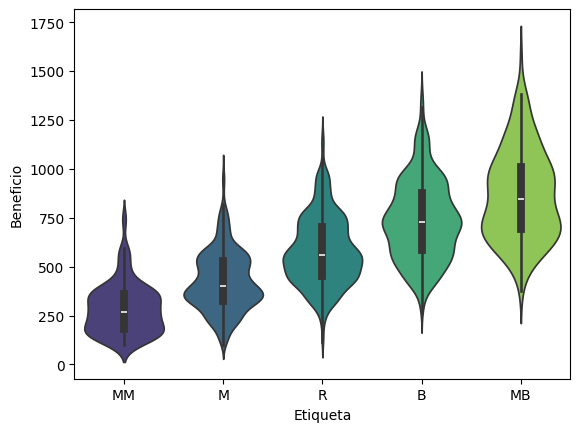

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.clf()
#sns.boxplot(x='Etiqueta',y='Beneficio',data=vinosDep,palette='viridis')
sns.violinplot(x='Etiqueta',y='Beneficio',data=vinosCompra,palette='viridis')
#sns.stripplot(x='Etiqueta',y='Beneficio',data=vinosDep,palette='viridis')
#sns.swarmplot(x='Etiqueta',y='Beneficio',data=vinosDep,palette='viridis')
plt.show()

Clasificación tiene también distirbuciones distintas.



<Axes: xlabel='Region', ylabel='Beneficio'>

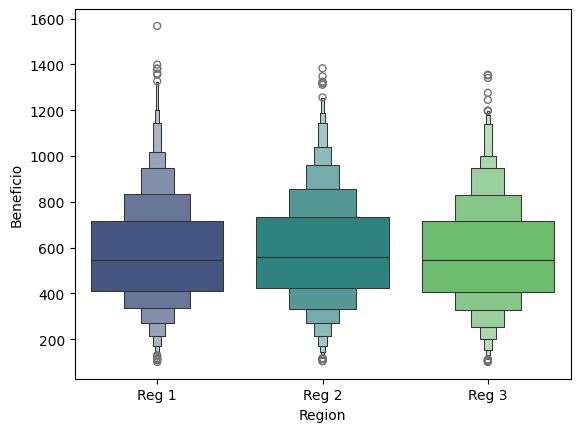

In [41]:
#sns.boxplot(x='Etiqueta',y='Beneficio',data=vinosDep,palette='viridis')
#sns.violinplot(x='Clasificacion',y='Beneficio',data=vinosCompra,palette='viridis')
sns.boxenplot(x='Region',y='Beneficio',data=vinosCompra,palette='viridis')
#sns.swarmplot(x='Etiqueta',y='Beneficio',data=vinosDep,palette='viridis')


De esta forma podemos explorar gráficamente las relaciones bivariantes entre variables del archivo.

# (Opcional) Transformaciones de las variables continuas

El principal objetivo de las transformaciones de las variables continuas es conseguir linealidad frente a la variable objetivo. De esta forma se prueban las transformaciones típicas (log, exp, potencias y raíces) y se escoge aquella que mayor coeficiente de correlación o valor V de Cramer presenta con la respuesta continua (o binaria en su caso).

Definamos pues una función que nos facilite este proceso, de tal manera que aplique sobre una columna genérica y una variable objetivo e implemente la posibilidad de actuar en base al coeficiente de correlación (relación lineal de continua-continua) o al valor V de cramer (asociación general entre categórica-categórcia).

La función va a hacer una traslación a valores positivos de la variable que encuentre (predictor continuo siempre!! no tiene sentido el log de una categórica!) y seguidamente va a generar las posibles transformaciones típicas (log, exp, potencias y raíces 2 y 4) para aplicar estos criterios sobre todas las posibilidades y escoger la que mejor valor obtenga. Vamos a ello!

Aquí hay un workround para conseguir que los nombres de las transformadas se conserven en el dataset de salida que es fruto de un apply al input continuo. Seguro se puede mejorar!


In [106]:
## Función mejor tranformación ##
from sklearn.preprocessing import scale

# Busca la transformación de variables input de intervalo que maximiza la VCramer o
# la correlación tipo Pearson con la objetivo
def mejorTransf (vv,target, name=False, tipo = 'cramer', graf=False):

    # Escalado de datos (evitar fallos de tamaño de float64 al hacer exp de número grande..cosas de python)
    vv = pd.Series(scale(vv), name=vv.name)
    # Traslación a valores positivos de la variable (sino falla log y las raíces!)
    vv = vv + abs(min(vv))+0.0001

    # Definimos y calculamos las transformaciones típicas
    transf = pd.DataFrame({vv.name + '_ident': vv, vv.name + '_log': np.log(vv), vv.name + '_exp': np.exp(vv), vv.name + '_sqrt': np.sqrt(vv),
                         vv.name + '_sqr': np.square(vv), vv.name + '_cuarta': vv**4, vv.name + '_raiz4': vv**(1/4)})

    # Distinguimos caso cramer o caso correlación
    if tipo == 'cramer':
      # Aplicar la función cramers_v a cada transformación frente a la respuesta
      tablaCramer = pd.DataFrame(transf.apply(lambda x: cramers_v(x,target)),columns=['VCramer'])

      # Si queremos gráfico, muestra comparativa entre las posibilidades
      if graf: px.bar(tablaCramer,x=tablaCramer.VCramer,title='Relaciones frente a ' + target.name).update_yaxes(categoryorder="total ascending").show()
      # Identificar mejor transformación
      best = tablaCramer.query('VCramer == VCramer.max()').index
      ser = transf[best[0]].squeeze()

    if tipo == 'cor':
      # Aplicar coeficiente de correlación a cada transformación frente a la respuesta
      tablaCorr = pd.DataFrame(transf.apply(lambda x: np.corrcoef(x,target)[0,1]),columns=['Corr'])
      # Si queremos gráfico, muestra comparativa entre las posibilidades
      if graf: px.bar(tablaCorr,x=tablaCorr.Corr,title='Relaciones frente a ' + target.name).update_yaxes(categoryorder="total ascending").show()
      # identificar mejor transformación
      best = tablaCorr.query('Corr.abs() == Corr.abs().max()').index
      ser = transf[best[0]].squeeze()

    # Aquí distingue si se devuelve la variable transformada o solamente el nombre de la transformación
    if name:
      return(ser.name)
    else:
      return(ser)

# Ejemplo de uso univariante
tr = mejorTransf(vinosCompra.Azucar,varObjCont, tipo='cramer', graf=True)

tr.head(),vinosCompra.Azucar.head()


(0    41.082063
 1    29.274329
 2    19.587200
 3    26.318044
 4    19.823564
 Name: Azucar_exp, dtype: float64,
 0    26.10
 1    14.80
 2     1.40
 3    11.25
 4     1.80
 Name: Azucar, dtype: float64)

**Nota**: Hay que tener en cuenta que se ha aplicado un escalado y traslación de los datos por lo que no debemos esperar que los valores correspondan a la transformación en bruto sobre la variable!!


### Aplicación en modadilad correlación

Aplicamos de forma masiva la función mejor transformación a todas las variables de tipo numérico presentes en el input de interés. PAra ello, llamamos dos veces a la función, una devuelve las transfroamciones y la otra el nombre de las columnas que luego asociamos para obtener un solo dataset.


In [107]:
transf_cor = imputCompra.select_dtypes(include=np.number).apply(lambda x: mejorTransf(x,varObjCont, tipo='cor'))
transf_cor

,Acidez,AcidoCitrico,Azucar,CloruroSodico,Densidad,pH,Sulfatos,Alcohol,CalifProductor,PrecioBotella,n_missings,aleatorio,aleatorio2
0,8.309692,5.573396,3.715572,1.578977,1.452933,1.826596,26.107661,2.136969,1.364559,1.000000e-08,3.670765e+00,1.027092,0.821545
1,37.422272,5.132738,3.376711,3.043717,1.334062,1.716307,20.585568,2.490295,1.671222,2.613945e+00,1.000000e-08,1.175518,1.023282
2,1.172213,21.566661,2.974876,3.053229,1.466976,1.750982,13.508539,1.808305,1.364559,1.262167e+01,3.670765e+00,1.159424,-1.584264
3,9.157458,49.727992,3.270255,2.904218,1.338271,2.380313,16.231467,2.056301,0.964915,9.569796e-01,1.000000e-08,1.107881,0.787513
4,5.697821,22.873545,2.986871,2.048201,1.063663,1.703122,27.556475,1.884636,1.671222,5.055726e+00,1.000000e-08,1.113938,1.150642
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4993,8.460769,21.566661,2.971878,3.100785,1.254265,1.150051,13.219837,1.482836,1.671222,1.167482e+01,1.000000e-08,1.072015,0.984123
4994,12.773082,16.070526,4.549229,3.065910,1.332484,1.895241,29.085690,2.049436,1.364559,4.695808e+00,1.468229e+01,0.917552,0.976245
4995,9.637229,4.782869,1.658418,3.040547,1.230027,1.658414,134.840816,1.986578,1.929752,3.028425e-01,3.670765e+00,0.849801,0.944045
4996,8.385061,3.962111,4.042437,3.173705,1.315349,1.772310,16.948151,1.862065,0.964915,1.000000e-08,3.670765e+00,1.040832,-0.215820


In [108]:
# Aplicar a las variables continuas la mejor transformación según correlacion frente a varObjCont
transf_cor = imputCompra.select_dtypes(include=np.number).apply(lambda x: mejorTransf(x,varObjCont, tipo='cor'))

# Pedir los nombres de las transformadas
transf_cor_names = imputCompra.select_dtypes(include=np.number).apply(lambda x: mejorTransf(x,varObjCont,tipo='cor', name=True))
# Asignar nombres a las columnas de salida del proceso
transf_cor.columns = transf_cor_names.values
transf_cor.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Acidez_sqr           4998 non-null   float64
 1   AcidoCitrico_exp     4998 non-null   float64
 2   Azucar_ident         4998 non-null   float64
 3   CloruroSodico_ident  4998 non-null   float64
 4   Densidad_raiz4       4998 non-null   float64
 5   pH_sqrt              4998 non-null   float64
 6   Sulfatos_exp         4998 non-null   float64
 7   Alcohol_sqrt         4998 non-null   float64
 8   CalifProductor_sqrt  4998 non-null   float64
 9   PrecioBotella_sqr    4998 non-null   float64
 10  n_missings_sqr       4998 non-null   float64
 11  aleatorio_raiz4      4998 non-null   float64
 12  aleatorio2_log       4998 non-null   float64
dtypes: float64(13)
memory usage: 507.7 KB


### Aplicación en modadilad V de Cramer

Mismo procedimiento en modo V de Cramer. Recordemos que podría salir a relucir relaciones no lineales que no serían captadas en el modo correlación!


In [109]:
# Aplicar a las variables continuas la mejor transfromación según cramer frente a varObjCont
transf_cramer = imputCompra.select_dtypes(include=np.number).apply(lambda x: mejorTransf(x,varObjCont, tipo='cramer'))
transf_cramer_names = imputCompra.select_dtypes(include=np.number).apply(lambda x: mejorTransf(x,varObjCont,tipo='cramer', name=True))


In [110]:
# Asignar nombres a las columnas de salida del proceso
transf_cramer.columns = transf_cramer_names.values
transf_cramer.info()
transf_cramer.head()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Acidez_sqr            4998 non-null   float64
 1   AcidoCitrico_exp      4998 non-null   float64
 2   Azucar_exp            4998 non-null   float64
 3   CloruroSodico_cuarta  4998 non-null   float64
 4   Densidad_sqr          4998 non-null   float64
 5   pH_ident              4998 non-null   float64
 6   Sulfatos_sqrt         4998 non-null   float64
 7   Alcohol_sqr           4998 non-null   float64
 8   CalifProductor_raiz4  4998 non-null   float64
 9   PrecioBotella_exp     4998 non-null   float64
 10  n_missings_log        4998 non-null   float64
 11  aleatorio_sqr         4998 non-null   float64
 12  aleatorio2_sqrt       4998 non-null   float64
dtypes: float64(13)
memory usage: 507.7 KB


,Acidez_sqr,AcidoCitrico_exp,Azucar_exp,CloruroSodico_cuarta,Densidad_sqr,pH_ident,Sulfatos_sqrt,Alcohol_sqr,CalifProductor_raiz4,PrecioBotella_exp,n_missings_log,aleatorio_sqr,aleatorio2_sqrt
0,8.309692,5.573396,41.082063,6.215881,19.859349,3.336453,1.806164,20.854177,1.168144,1.000100,0.65020,1.238439,1.507983
1,37.422272,5.132738,29.274329,85.825686,10.032494,2.945709,1.739135,38.459477,1.292758,5.036796,-9.21034,3.646145,1.668026
2,1.172213,21.566661,19.587200,86.903511,21.447879,3.065938,1.613481,10.692680,1.168144,34.907388,0.65020,3.265409,0.452878
3,9.157458,49.727992,26.318044,71.140512,10.288497,5.665889,1.669417,17.879158,0.982301,2.659806,-9.21034,2.269584,1.482539
4,5.697821,22.873545,19.823564,17.599088,1.638442,2.900623,1.821054,12.615648,1.292758,9.473459,-9.21034,2.370763,1.777701


Podemos generar los conjuntos de datos que tengan las mejores transformaciones con cada alternativa uniéndolos con el input compra. Se esta forma, aumentamos posibilidades de cara a la creación de modelos y tal vez hay algún patrón de transformada que resulte interesante.

En nuestro caso, reservaremos el uso de las transformaciones al apartado de selección automática de variables por facilitar. Guardamos los archivos con las transformaciones para tenerlos a mano llegado el momento.


In [111]:
# Input con transfromadas según correlación
imput_transf_cor = imputCompra.reset_index(drop=True).join(transf_cor)

todo_cont_cor = imput_transf_cor.join(varObjCont)

todo_cont_cor.to_csv('/content/drive/MyDrive/Material Minería de Datos 2025_26_Online/PARTE I_Depuracion y Regresiones/Dia2_Regresion Lineal/todo_cont_cor.csv')

# Input con transfromadas según cramer
imput_transf_cramer = imputCompra.reset_index(drop=True).join(transf_cramer)

todo_cont_cramer = imput_transf_cor.join(varObjCont)

todo_cont_cramer.to_csv('/content/drive/MyDrive/Material Minería de Datos 2025_26_Online/PARTE I_Depuracion y Regresiones/Dia2_Regresion Lineal/todo_cont_cramer.csv')


In [112]:
todo_cont_cor.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Acidez               4998 non-null   float64 
 1   AcidoCitrico         4998 non-null   float64 
 2   Azucar               4998 non-null   float64 
 3   CloruroSodico        4998 non-null   float64 
 4   Densidad             4998 non-null   float64 
 5   pH                   4998 non-null   float64 
 6   Sulfatos             4998 non-null   float64 
 7   Alcohol              4998 non-null   float64 
 8   CalifProductor       4998 non-null   int64   
 9   PrecioBotella        4998 non-null   float64 
 10  Etiqueta             4998 non-null   category
 11  Clasificacion        4998 non-null   category
 12  Region               4998 non-null   category
 13  n_missings           4998 non-null   int64   
 14  aleatorio            4998 non-null   float64 
 15  aleatorio2           

Podemos comprobar si las transformaciones han aumentado el valor de correlación lineal con la respuesta.

En el gráfico de correlaciones se intuye la baja relación lineal presente entre las variables del archivo 2 a 2. Esto nos hace pensar que las variables continuas, a diferencia de las categóricas, no van a tener demasiada influencia en los modelos de regresión frente a la respuesta (véase el poco color que presenta la fila 1). Por otro lado, podemos estar respirar con cierta tranquilidad ante el hecho de la baja relación entre los predictores (véase la ausencia de color en todo el gráfico), cosa que evitará problemas de colinealidad en los modelos.

Es evidente que, las relaciones de cada variable con su transformada han de ser muy elevadas, ya que hay un mecanismo que genera una en función exacta de la otra, por lo que esto es normal.

**Nota:** La principal precaución que hay que tener es no considerar un modelo completo con todas al mismo tiempo puesto que se pueden generar los problemas de colinealidad. Solamente utilizaremos el set completo de variables cuando hagamos un proceso de selección automática de variables, proceso en el cual se elegirán las que más R2 aporten al modelo.


In [113]:
# Matriz de correlaciones incluyendo transformaciones
corr = todo_cont_cor.select_dtypes(include=np.number).corr()
corr.style.background_gradient(cmap='viridis').format(precision=2)
#sns.heatmap(corr, annot=True)


,Acidez,AcidoCitrico,Azucar,CloruroSodico,Densidad,pH,Sulfatos,Alcohol,CalifProductor,PrecioBotella,n_missings,aleatorio,aleatorio2,Acidez_sqr,AcidoCitrico_exp,Azucar_ident,CloruroSodico_ident,Densidad_raiz4,pH_sqrt,Sulfatos_exp,Alcohol_sqrt,CalifProductor_sqrt,PrecioBotella_sqr,n_missings_sqr,aleatorio_raiz4,aleatorio2_log,Beneficio
Acidez,1.00,-0.02,-0.02,0.01,0.01,0.01,0.01,-0.00,0.01,-0.00,0.00,0.03,0.00,0.96,-0.01,-0.02,0.01,0.00,0.02,0.00,-0.01,0.00,-0.01,0.00,0.03,-0.02,-0.04
AcidoCitrico,-0.02,1.00,0.01,-0.01,-0.01,-0.02,0.00,0.02,0.06,-0.01,-0.02,0.03,0.00,-0.03,0.74,0.01,-0.01,-0.01,-0.02,0.01,0.01,0.06,-0.02,-0.01,0.03,0.01,0.00
Azucar,-0.02,0.01,1.00,-0.01,0.02,0.01,-0.00,-0.03,0.00,-0.02,0.00,0.01,0.01,-0.02,0.00,1.00,-0.01,0.01,0.00,-0.00,-0.03,0.01,-0.02,0.00,0.01,0.02,-0.02
CloruroSodico,0.01,-0.01,-0.01,1.00,0.02,-0.00,-0.01,-0.01,0.01,-0.01,0.01,0.01,-0.00,0.01,-0.01,-0.01,1.00,0.02,-0.01,-0.00,-0.01,0.02,-0.01,0.01,0.01,-0.00,-0.01
Densidad,0.01,-0.01,0.02,0.02,1.00,-0.02,-0.01,0.01,0.03,0.01,-0.00,0.02,-0.00,0.01,-0.01,0.02,0.02,0.86,-0.01,-0.01,0.01,0.03,0.01,-0.01,0.02,0.00,-0.01
pH,0.01,-0.02,0.01,-0.00,-0.02,1.00,-0.01,-0.01,-0.08,-0.00,0.05,0.00,0.01,0.01,0.01,0.01,-0.00,-0.01,0.97,-0.01,-0.01,-0.09,-0.00,0.04,-0.00,-0.00,0.02
Sulfatos,0.01,0.00,-0.00,-0.01,-0.01,-0.01,1.00,0.00,0.02,0.00,-0.01,0.01,-0.01,0.01,0.00,-0.00,-0.01,-0.00,0.00,0.73,0.00,0.02,0.00,-0.01,0.01,-0.02,-0.00
Alcohol,-0.00,0.02,-0.03,-0.01,0.01,-0.01,0.00,1.00,-0.03,0.01,0.03,-0.00,0.01,0.00,0.02,-0.03,-0.01,0.02,-0.02,-0.01,0.98,-0.04,0.00,0.03,-0.01,0.00,0.08
CalifProductor,0.01,0.06,0.00,0.01,0.03,-0.08,0.02,-0.03,1.00,0.02,-0.01,0.01,0.01,0.00,0.04,0.00,0.01,0.03,-0.07,0.01,-0.02,0.97,0.02,-0.01,0.01,0.01,-0.05
PrecioBotella,-0.00,-0.01,-0.02,-0.01,0.01,-0.00,0.00,0.01,0.02,1.00,0.01,-0.01,-0.00,-0.01,-0.02,-0.02,-0.01,0.00,-0.01,0.00,0.00,0.02,0.94,0.00,-0.03,-0.00,0.01


No parece que haya mejorado mucho...Este estudio nos lleva a pensar que las variables continuas no van a aportar mucho a nuestro modelo de regresión, si bien puede suceder que en presencia de otras variables (por ejemplo las categóricas) la influencia de éstas pueda aumentar debido al distinto comportamiento (pendiente) que presenten con la respuesta en los distintos grupos que forma la variable categórica.

Por este motivo, es positivo complementar este análisis descriptivo con la información que dan los modelos sobre la importancia de variables, ya que dentro de modelo, la influencia de la variable se entiende a niveles constantes de todas las demás presentes en el mismo.


### Tramificación de variables continuas. Binning

En cualquier caso, una vía que se puede explorar aquí para conseguir mayor influencia de las continuas es intentar tramificarlas (pasarlas a categóricas) de tal manera que se puedan descubrir patrones muy alejados d la linealidad que esta puedan contener. En el mundo de la tramificación existen dos estrategias fundamentales,

1)  tramos ad-hoc para una mejor interpretabilidad (por ejemplo tramos de edad acordes a los que se utilizan en las estadísticas oficiales) en los que normalmente se realizan particiones más o menos equidistantes o basadas en un fundamento anterior.

2)  tramos que maximicen cierta relación con la variable objetivo. Se pueden generar los puntos de corte de la variable a tramificar tales que los grupos creados sean lo más distintos entre sí en distribución de la variable respuesta, con lo que se "aseguran" tramos con capacidad de discriminar frente al objetivo. Suelen funcionar bien este tipo de tramificaciones pero tienen cierto peligro de sobreajustar a los datos de entrenamiento...Una de las formas de hacerlo es mediante árboles de regresión/clasificación.

Un árbol realiza particiones binarias de las variables con la premisa de encontrar las mayores diferencias entre los grupos que va formando, justo lo que buscamos!

Hay otro tipo de disretizadores en sklearn y seguramente en otros paquetes de python.

Vamos a ilustrar el proceso de binning con la variable azucar que, como continua no vale mucho a nivel predictivo (como muchas otras continuas del archivo..). Trataremos de pasar de una variable continua que no presenta linealidad a una categórica con pocos grupos que generen máximas diferencias en la objetivo a ver si mejora su capacidad predictiva.


In [114]:
%pip install -q --upgrade pip
%pip install -q "protobuf==5.26.1" "ortools==9.11.4210" "optbinning==0.20.1" "ropwr>=1.1.0" "absl-py>=2.3.0"

import optbinning

In [120]:
# !pip install protobuf==5.29.1
# !pip install optbinning
# http://gnpalencia.org/c/binning_continuous.html
from optbinning import ContinuousOptimalBinning

optb = ContinuousOptimalBinning(name='Azucar', dtype="numerical", max_n_bins=2)
optb.fit(imputCompra['Azucar'].values, varObjCont)

x_transform_bins = optb.transform(imputCompra['Azucar'].values, metric="bins")
x_transform_bins

# Podemos incluir la variable directamente al dataset
imputCompra['Azucar_rec'] = x_transform_bins
vinosCompra['Azucar_rec'] = x_transform_bins


In [52]:

#import seaborn as sns

<Axes: ylabel='Beneficio'>

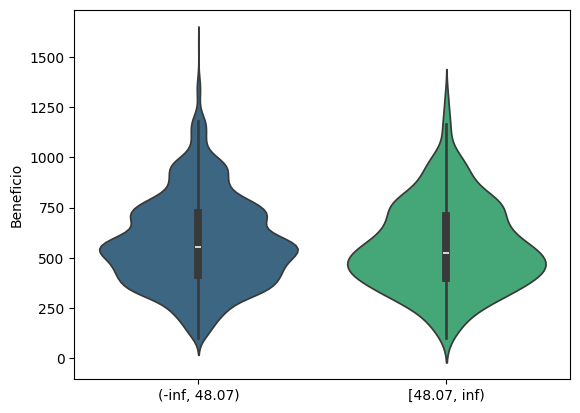

In [121]:
sns.violinplot(x=x_transform_bins,y=varObjCont,palette='viridis')



Podemos probar a realizar el binning de alguna (o todas) las variables continuas que no parezcan relevantes en el anterior análisis en pos de la mejor capacidad predictiva frente al modelo. Recomendable evaluar la salida sin restricciones del árbol y tal vez refinar con un máximo de categorías de salida en su caso. EL violin, revela las ligerísimas diferencias en distribución que se consiguen en este caso tramificando la variable Azucar.

En cualquier caso, es una opción interesante a considerar para la modelización predictiva.

**Cuidado con pasarse de categorías!!** Como ya sabemos las variables categóricas "consumen" grados de libertad y añaden k-1 parámetros al modelo, aumentando la complejidad del mismo y puediendo incurrir en problemas de robustez o generalización a nuevos datos. Por ello, hay que controlar el crecimiento de categorías de los factores.

Son muchas las posibilidades sobre transformaciones de variables de cara a la modelización predictiva. Una estrategia interesante es aplicar múltiples vías de modelización con distintas posibilidades y comparar los resultados finales, decidiendo en base a la capacidad preditiva de la solución y su interpretabilidad.

Por el momento, nos centraremos en la creación de modelos de regresión para estimar el **Beneficio de los vinos con Compra = 1** debido a esa mejor en la distribución de la respuesta.


# Modelos de regresión lineal para la predicción del beneficio del vino

En esta sección se ajustan distintos modelos de regresión lineal para predecir el beneficio de los vinos con compra = 1. En primer lugar, tomamos la partición training (donde ajustamos el modelo) y test (donde probamos su capacidad).


## Dos filosofías de ajuste de modelos en python

La filosofía de muchos de los modelos predictivos en python (muy enfocado a la automatización para la prediccion) es la de tener por separado la matriz de predictores y el vector de variable objetivo ya que bajo este esquema están programados los procedimientos. Sin embargo, esto no es algo directo cuando existen variables categóricas en el dataset. En general, estas variables no son aceptadas tal cual en los modelos y hay que realizar un paso previo de creación de variables **dummy** generando lo que se conoce como la **matriz de diseño** del modelo.

**Matriz de diseño**: Es el archivo de input de los predictores con las variables continuas tal cual y las categóricas extendidas en *k-1* dummies. Además se añade una variable constante a dicha matriz. De esta forma, por columnas obtenemos los efectos explícitos de cada beta a estimar por el modelo. Bajo este paradigma se ajustan los modelos de la famosa librería sklearn de machine learning.

Recordamos aquí lo que ya hemos comentado. Si tengo 4 categorías en un factor y pretendo generar dummies para todas, qué pasa?? Pues que tenemos una combinación lineal exacta de las variables en la matriz y por tanto no se puede invertir (algo necesario para la estimación por mínimos cuadrados de los parámetros del modelo) y todo se va al garete!! Por ello habría que tener en cuenta esto para generar solamente 3 dummies quedando "implícito" el efecto de la cuarta cuando todas ellas tomen el valor 0. Ok...y En este momento nos preguntamos, y donde va el efecto de esta variable? es decir, como se contabiliza en el modelo? Pues precisamente en nuestra querida constante $\beta_0$ u ordenada en el origne de la ecuación de regresión. Vale, y donde está esta constante...pues depende..si generamos todo "a mano" es decir la extensión en k-1 dummies, tendríamos que añadir, así mismo esta constante (en realidad un vector de todo 1's en la matriz de diseño).

**Interfaz fórmula**: Algo muy guay que tiene R es la interfaz fórmula, mediante la cual podemos undicar el modelos que queramos ajustar de una forma muy visual. Por ejemplo, Beneficio en función de varios efectos. No tenemos más que poner **'Beneficio \~ Efecto1 + Efecto2 +..+EfectoN'** y por debajo se estarán generando estas matrices de diseño con sus dummies en caso de necesidad y su constante y de todo. De esta forma tenemos un único data_train y un único data_test (en caso de partición) que incluyen las variables objetivo y mediante la fórmula se especifica el modelo y por tanto las matrices de diseño a crear como subconjunto del data utilizado. Frecuentemente de cara a la modelización manual es bastante más cómoda esta opción que tener que eliminar de la matriz de diseño columna por columna y sin confundirnos.. Es algo tedioso.

**El nexo: patsy**: Dicho esto, un paquete muy interesante que nos facilita mucho la conexión entre fórmula y matriz explícita es **patsy**. Maravillosa función dmatrices que mediante una fórmula dada genera las matrices explícitas de diseño para poder utilizarlas en sklearn o donde nos haga falta!!

Vale pues estamos en disposición de jugar!!



## (Opcional) Partición training-test

De cara al ajuste manual de modelos, generamos la partición training-test. Con la primera ajustamos el modelo y con la segunda obtenemos predicciones (obviando la variable objetivo de este conjunto) y evaluamos el error cometido y el posible sobreajuste. Para esta tarea tenemos la función **train_test_split** de sklearn que realiza la partición estratificada por la variable objetivo (para mantener proporciones o distribución) con los tamaños dados y devuelve los objetos training (X de predictores e y de respuesta) y test (X de predictores e y de respuesta). La semilla hay que fijarla para obtener resultados reproducibles y que no cambien en cada ejecución.


In [122]:
# Función necesaria
from sklearn.model_selection import train_test_split

# Creamos 4 objetos: predictores para tr y tst y variable objetivo para tr y tst.
X_train, X_test, y_train, y_test = train_test_split(imputCompra, varObjCont, test_size=0.2, random_state=42)

# Comprobamos dimensiones
print('Training dataset shape:', X_train.shape, y_train.shape)
print('Testing dataset shape:', X_test.shape, y_test.shape)


Training dataset shape: (3998, 17) (3998,)
Testing dataset shape: (1000, 17) (1000,)


In [123]:
X_train

,Acidez,AcidoCitrico,Azucar,CloruroSodico,Densidad,pH,Sulfatos,Alcohol,CalifProductor,PrecioBotella,Etiqueta,Clasificacion,Region,n_missings,aleatorio,aleatorio2,Azucar_rec
1738,0.13,-0.97,12.85,0.042,0.99581,4.01,1.94,8.1,3,5.72,R,*,Reg 1,2,0.527198,0.471817,"(-inf, 48.07)"
3986,1.93,0.25,1.80,0.555,0.96673,2.79,0.44,10.1,2,1.66,R,***,Reg 3,0,0.774145,0.140478,"(-inf, 48.07)"
2915,0.52,0.21,2.20,-0.315,0.93487,3.40,0.63,9.4,2,2.75,R,*,Reg 2,0,0.299655,0.705586,"(-inf, 48.07)"
1595,-0.65,0.60,5.85,0.033,0.96870,1.16,0.54,18.9,4,3.19,B,**,Reg 3,1,0.855792,0.146853,"(-inf, 48.07)"
3213,-0.04,-2.27,2.60,0.286,1.01619,2.97,0.64,7.8,2,4.78,R,***,Reg 3,1,0.176570,0.171401,"(-inf, 48.07)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4426,0.31,-0.84,2.30,0.042,0.98952,3.32,0.41,3.8,2,3.92,B,**,Reg 2,0,0.153210,0.562817,"(-inf, 48.07)"
466,0.56,0.28,2.70,0.593,0.94351,4.20,0.71,18.8,4,2.19,R,**,Reg 1,1,0.302035,0.813696,"(-inf, 48.07)"
3092,-0.09,1.36,6.20,0.078,0.99530,2.18,0.77,13.2,5,4.56,R,**,Reg 2,1,0.781130,0.586253,"(-inf, 48.07)"
3772,0.37,-0.07,6.60,0.321,0.98664,2.69,0.21,9.6,2,1.00,B,**,Reg 1,0,0.764805,0.833831,"(-inf, 48.07)"


**Filosofía fórmula**: Tenemos esta posibilidad en python para los modelos de regresión. Generemos primero el data_train con la variable objetivo dentro y posteriormente hacemos uso de la api para fórmulas de statmodels en su variante para regresión por mínimos cuadrados ordinarios.



In [124]:
# Genero el training con la objetivo dentro
data_train = X_train.join(y_train)
data_train.head()

,Acidez,AcidoCitrico,Azucar,CloruroSodico,Densidad,pH,Sulfatos,Alcohol,CalifProductor,PrecioBotella,Etiqueta,Clasificacion,Region,n_missings,aleatorio,aleatorio2,Azucar_rec,Beneficio
1738,0.13,-0.97,12.85,0.042,0.99581,4.01,1.94,8.1,3,5.72,R,*,Reg 1,2,0.527198,0.471817,"(-inf, 48.07)",621
3986,1.93,0.25,1.80,0.555,0.96673,2.79,0.44,10.1,2,1.66,R,***,Reg 3,0,0.774145,0.140478,"(-inf, 48.07)",329
2915,0.52,0.21,2.20,-0.315,0.93487,3.40,0.63,9.4,2,2.75,R,*,Reg 2,0,0.299655,0.705586,"(-inf, 48.07)",459
1595,-0.65,0.60,5.85,0.033,0.96870,1.16,0.54,18.9,4,3.19,B,**,Reg 3,1,0.855792,0.146853,"(-inf, 48.07)",742
3213,-0.04,-2.27,2.60,0.286,1.01619,2.97,0.64,7.8,2,4.78,R,***,Reg 3,1,0.176570,0.171401,"(-inf, 48.07)",715


**Ejemplo rápido de ajuste de modelo mediante fórmula**

Tan facil como lo siguiente.


In [125]:
# Importamos la api para fórmulas (en concreto ols para regresión)
from statsmodels.formula.api import ols

# Ajusto regresión de ejemplo
results = ols('Beneficio ~ Etiqueta + Clasificacion + Alcohol',data=data_train).fit()
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:              Beneficio   R-squared:                       0.431
Model:                            OLS   Adj. R-squared:                  0.429
Method:                 Least Squares   F-statistic:                     335.3
Date:                Thu, 15 Jan 2026   Prob (F-statistic):               0.00
Time:                        14:52:17   Log-Likelihood:                -26200.
No. Observations:                3998   AIC:                         5.242e+04
Df Residuals:                    3988   BIC:                         5.248e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept               211.89

Se puede comprobar que el funcionamiento es adecuado en tanto en cuanto la variable categórica Etiqueta aparece con 5-1 = 4 efectos en el modelo (siendo el restante 'MM' recogido por la constante $\beta_0$). Además, vemos que se conserva el órden de las categorías que hemos especificado y también que el efecto tiene pinta de monótono creciente con etiqueta puesto que los betas van aumentando con el aumento de etiqueta. Si nos ponemos a valorar, pues es un modelo bastante malo con un R2 de 0,37 pero todos los parámetros son significativos a nivel estadístico (es decir, su parámetro es distinto de 0 o el IC no contiene al valor 0). Ajuste muy pobre con significación paramétrica.

Lo que siempre haremos es un modelo completo de referencia para valorar la capacidad (sobre training) de este y tomarla como base para la generación de modelos más sencillos que mantengan valor predictivo en training y lo mejoren en test.

## Modelo completo de referencia

Para utilizar la interfaz fórmula proporcionada por la api, tenemos que especificar todos los efectos...cosa que no me gusta nada (R tiene la posibilidad de poner 'Beneficio \~ .' y se sobreentiende que quieres todos los efectos) pero la vida es durilla a veces jeje.

Venga pues vamos a facilitarnos la vida un poco y generamos una función que concatene todos los efectos como string e incluso podamos eliminar algunos a placer, obteniendo la fórmula de manera automática.


In [126]:
# Función para generar la fórmula por larga que sea
def ols_formula(df, dependent_var, *excluded_cols):
    df_columns = list(df.columns.values)
    df_columns.remove(dependent_var)
    for col in excluded_cols:
        df_columns.remove(col)
    return dependent_var + ' ~ ' + ' + '.join(df_columns)

# Aplicamos a fórmula de modelo completo
form=ols_formula(data_train,'Beneficio','Azucar')
form


'Beneficio ~ Acidez + AcidoCitrico + CloruroSodico + Densidad + pH + Sulfatos + Alcohol + CalifProductor + PrecioBotella + Etiqueta + Clasificacion + Region + n_missings + aleatorio + aleatorio2 + Azucar_rec'

Aplicamos el modelo completo utilizando esta fórmula.



In [127]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.formula.api import ols

# Ajusto regresión según fórmula completa
modeloC = ols(form,data=data_train).fit()
print(modeloC.summary())
#vif_modelo(form,data=data_train)

                            OLS Regression Results                            
Dep. Variable:              Beneficio   R-squared:                       0.434
Model:                            OLS   Adj. R-squared:                  0.431
Method:                 Least Squares   F-statistic:                     132.6
Date:                Thu, 15 Jan 2026   Prob (F-statistic):               0.00
Time:                        14:56:08   Log-Likelihood:                -26187.
No. Observations:                3998   AIC:                         5.242e+04
Df Residuals:                    3974   BIC:                         5.257e+04
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

Modelo completo bastante sobreparametrizado por lo que se ve, con muchos efectos no significativos cuya aportación al R2 será seguramente despreciable y puedan ser eliminados y con una capacidad bastante baja con R2 de 0.43...mal augurio. Conjunto de datos dificil de modelizar.. Pero hay que tirar palante con lo que tenemos y luchar!

**Filosofía matriz de diseño explícita**

El paquete **pasty** resulta muy útil para generar las *matrices de diseño* de un modelo basadas en una fórmula concreta. Esto nos permitirá utilizar cualquier modelo de predicción de python que no acepte directamente la interfaz fórmula. Es evidente que podríamos hacer esta operación "a mano", generando la *extensión en dummies* de los factores y la posterior adición de una constante $\beta_0$ para que se refleje en el modelo, pero pienso que es más intuitivo utilizar la fórmula y así evitar errores.

Aquí podemos utilizar el modelo de statmodels **OLS** pensado para filosofía matriz explícita o cualquier modelo sklearn.

**Nota**: En realidad, si este fuera nuesto verdadero modus operandi, lo suyo sería generar con pasty sobre imput completo y luego tomar la partición training-test desde la matriz de diseño de datos completos!! De momento lo hacemos solamente con trianing para ejemplificar el uso y poder aplicar la función de importancia de las variables dentro de modelo que no sunciona bajo el paradigma fórmula (no admite factores!).


In [128]:
import statsmodels.api as sm
import patsy

# Generamos las matrices de diseño según la fórmula de modelo completo
y, X = patsy.dmatrices(form, data_train, return_type='dataframe')

X

,Intercept,Etiqueta[T.M],Etiqueta[T.R],Etiqueta[T.B],Etiqueta[T.MB],Clasificacion[T.*],Clasificacion[T.**],Clasificacion[T.***],Clasificacion[T.****],Region[T.Reg 2],...,CloruroSodico,Densidad,pH,Sulfatos,Alcohol,CalifProductor,PrecioBotella,n_missings,aleatorio,aleatorio2
1738,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.042,0.99581,4.01,1.94,8.1,3.0,5.72,2.0,0.527198,0.471817
3986,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.555,0.96673,2.79,0.44,10.1,2.0,1.66,0.0,0.774145,0.140478
2915,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,-0.315,0.93487,3.40,0.63,9.4,2.0,2.75,0.0,0.299655,0.705586
1595,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.033,0.96870,1.16,0.54,18.9,4.0,3.19,1.0,0.855792,0.146853
3213,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.286,1.01619,2.97,0.64,7.8,2.0,4.78,1.0,0.176570,0.171401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4426,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.042,0.98952,3.32,0.41,3.8,2.0,3.92,0.0,0.153210,0.562817
466,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.593,0.94351,4.20,0.71,18.8,4.0,2.19,1.0,0.302035,0.813696
3092,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.078,0.99530,2.18,0.77,13.2,5.0,4.56,1.0,0.781130,0.586253
3772,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.321,0.98664,2.69,0.21,9.6,2.0,1.00,0.0,0.764805,0.833831


In [129]:

# Ahora podemos aplicar la función "oficial" de statmodels OLS (con formato y,X)
model=sm.OLS(y,X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:              Beneficio   R-squared:                       0.434
Model:                            OLS   Adj. R-squared:                  0.431
Method:                 Least Squares   F-statistic:                     132.6
Date:                Thu, 15 Jan 2026   Prob (F-statistic):               0.00
Time:                        14:59:59   Log-Likelihood:                -26187.
No. Observations:                3998   AIC:                         5.242e+04
Df Residuals:                    3974   BIC:                         5.257e+04
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

Podemos comprobar que el modelo es exactamente el mismo que el ajustado mediante la fórmula y la función *ols*.


Ahora si que si! Obtenemos un gráfico de importancia de las variables del modelo completo con el efecto de las categorías de las nominales por separado. Claramente lo que se podía esperar, las categorías de Clasificación y Etiqueta son las de mayor importancia para el modelo.

**Nota**: Otro método popular para la evaluación de la importancia de variables en el modelo es la comparación de valor de los parámetros en un modelo conlos datos escalados. La idea es que si las variables tienen la misma escala, parámetro mayor (ante un aumento unitario en la misma escala de medida..) se asocia con una fuerza de explicación o cambio por unidad mayor, por lo tanto mayor aportación al R2 del modelo. Por si lo vierais por ahí.

A partir del modelo completo de referencia (en cualquier variante ya sea OLS o bien ols) la idea es tratar de obtener un modelo más simple con capacidad de predicción parecida y buen aspecto del summary a nivel estadístico. De esta forma podemos trabajar hacia delante/atras siguiendo el ranking de importancia de cramer o este último dentro de modelo.



## Proceso backward para pruebas de modelos manuales

Vamos a generar un proceso backward eliminando variables secuencialmente según el p-valor. Presento solamente el final de mi periplo por la eliminación de variables + evaluación del summary.


In [135]:
# Proceso backward de eliminación de efectos según p-valor
form2=ols_formula(data_train,'Beneficio','Azucar','n_missings','aleatorio','aleatorio2','Sulfatos','PrecioBotella','AcidoCitrico',
                  'Densidad','CloruroSodico','pH','Region')

# Ajusto regresión sin prop_missings
modeloC2 = ols(form2,data=data_train).fit()
print(modeloC2.summary())


                            OLS Regression Results                            
Dep. Variable:              Beneficio   R-squared:                       0.433
Model:                            OLS   Adj. R-squared:                  0.431
Method:                 Least Squares   F-statistic:                     253.7
Date:                Thu, 15 Jan 2026   Prob (F-statistic):               0.00
Time:                        15:04:21   Log-Likelihood:                -26192.
No. Observations:                3998   AIC:                         5.241e+04
Df Residuals:                    3985   BIC:                         5.249e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

# Evaluación en el conjunto de test

Como podemos evaluar en test la capacidad de los modelos ajustados? Pues recurriendo a la obtención de las predicciones del modelo para test y comparando estas con los valores reales recogidos en y_test. Nos apoyamos en algunas funcionalidades de metric de sklearn (cientos de métricas disponibles!). En este caso, error cuadrático medio y coeficiente de determinación R2.


In [136]:
#from sklearn.metrics import mean_squared_error, r2_score
#execfile(r'C:\Users\Guille\Documents\Material Minería de Datos 2024_25 Gr3\NuestrasFunciones.py')

#plt.scatter(X_test.Acidez, y_test, color="black")
#plt.scatter(X_test.Acidez, vinos_y_pred, color="blue")

print('---------Modelo Completo-------------')
tr_tst_eval_lin(form,vinosCompra)
print('')
print('---------Modelo Backward-------------')
tr_tst_eval_lin(form2,vinosCompra)

---------Modelo Completo-------------
Coeficiente de determinación TRAINING:  0.43603374412066687 

Root Mean squared error TEST: 166.57
Coeficiente de determinación TEST: 0.43

---------Modelo Backward-------------
Coeficiente de determinación TRAINING:  0.4348454277743442 

Root Mean squared error TEST: 166.28
Coeficiente de determinación TEST: 0.43


Inapreciable cambio en R2 y algo de subida de mse en unas décimas con un modelo bastante más simple. De cara a la exploración de modelos el training-test está bien como esquema pero a la hora de comparar modelo finales y seleccionar el mejor en cuanto a sesgo-varianza de las estimaciones, la mejor opción es validación cruzada repetida.


# Evaluación por validación cruzada repetida

En esta sección vamos a valorar el ajuste de modelos por el proceso de validación cruzada repetida, en el que se generarán **n_splits** particiones del archivo, repitiendo el proceso con distintas semillas **n_repeats** veces. De esta forma, obtenemos **n_splits x n_repeats** modelos por fórmula especificada, pudiendo así promediar los resultados obtenidos bajo muchas muestras de training-test.

En este esquema, todas las observaciones del archivo son utilizadas en algún training para el ajuste del modelo y en algún test para su evaluación pero nunca simultáneamente. Así el modelo tiene instancias cambiantes para el ajuste de parámetros y para la predicción.


In [76]:
X

,Intercept,Etiqueta[T.M],Etiqueta[T.R],Etiqueta[T.B],Etiqueta[T.MB],Clasificacion[T.*],Clasificacion[T.**],Clasificacion[T.***],Clasificacion[T.****],Region[T.Reg 2],...,CloruroSodico,Densidad,pH,Sulfatos,Alcohol,CalifProductor,PrecioBotella,n_missings,aleatorio,aleatorio2
1738,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.042,0.99581,4.01,0.82,9.3,3.0,5.72,2.0,0.710850,0.005715
3986,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.555,0.96673,2.79,0.44,10.1,2.0,1.66,0.0,0.849624,0.407094
2915,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,-0.315,0.93487,3.40,0.63,9.4,2.0,2.75,0.0,0.762479,0.869093
1595,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.033,0.96870,3.81,0.54,18.9,4.0,3.19,1.0,0.696181,0.774159
3213,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.286,1.01619,2.97,0.64,15.2,2.0,4.78,1.0,0.549142,0.587275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4426,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.042,0.98952,3.32,0.41,3.8,2.0,3.92,0.0,0.722246,0.616800
466,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.593,0.94351,4.20,0.71,14.1,4.0,2.19,1.0,0.330523,0.938662
3092,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.078,0.99530,2.18,0.77,5.4,5.0,4.56,1.0,0.484168,0.679262
3772,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.321,0.98664,2.69,0.21,9.6,2.0,1.00,0.0,0.405611,0.462833


NOTA: Aquí hay que tener en cuenta que al utilizar sklearn, nos vemos obligados a considerar matrices explícitas de diseño.



### Comparación por validación cruzada. Función general

Una vez explorados varios modelos manuales, es bueno comprobar sus capacidades en un esquema de validación cruzada repetida con la intención de comprobar su estabilidad ante el remuestreo.

El objetivo fundamental en esta parte es seleccionar el mejor modelo en relación sesgo-varianza y complejidad.

Vamos a generar una función que automatice un poco el proceso de comparación por validación cruzada, de tal forma que pueda aplicar sobre cualquier fórmula epecificada. Luego será cuestión de enlistar todas las fómulas que queramos y pasar la función con un map().


In [77]:
# Función para comparación por validación cruzada
def cross_val_lin(formula, data, seed=12345):
      # Generamos las matrices de diseño según la fórmula de modelo completo
      y, X = patsy.dmatrices(formula, data, return_type='dataframe')

      model = LinearRegression()

      # Establecemos esquema de validación fijando random_state (reproducibilidad)
      cv = RepeatedKFold(n_splits=5, n_repeats=20, random_state=seed)

      # Obtenemos los resultados de R2 para cada partición tr-tst
      scores = cross_val_score(model, X, y, cv=cv)

      # Sesgo y varianza
      print('Modelo: ' + formula)
      print('Coeficiente de determinación R2: %.3f (%.3f)' % (np.mean(scores), np.std(scores)))

      #sns.violinplot(y=scores,palette='viridis')

      return(scores)


**Ejemplo de uso masivo para una lista de fórmulas distintas**



In [140]:
form3 = 'Beneficio ~ Etiqueta'
form4 = 'Beneficio ~ Etiqueta + Clasificacion'
form5 = 'Beneficio ~ Etiqueta + Clasificacion + Alcohol'
form6 = 'Beneficio ~ Etiqueta + Clasificacion + Alcohol + CalifProductor'
form7 = 'Beneficio ~ Etiqueta + Clasificacion + Alcohol + CalifProductor + Acidez'
form8 = 'Beneficio ~ Etiqueta + Clasificacion + Alcohol + CalifProductor + Acidez + Azucar_rec'
form9 = 'Beneficio ~ Etiqueta + Clasificacion + Alcohol + CalifProductor + Acidez + Azucar_rec + aleatorio'



# Creamos lista de fórmulas
list_form = [form,form2,form3,form4,form5,form6,form7,form8]
list_form

# Aplicamos a toda la lista la función creada (devuelve un dataframe pero está transpuesto)
list_res = pd.DataFrame(map(lambda x: cross_val_lin(x,vinosCompra, seed=2026),list_form))

# Trasnponer dataframe y pasar de wide a long (creando un factor variable con el nombre de cada fórmula de la lista[0,1,2,3])
results = list_res.T.melt()
results.columns = ['Modelo','R2']
results.head()


Modelo: Beneficio ~ Acidez + AcidoCitrico + CloruroSodico + Densidad + pH + Sulfatos + Alcohol + CalifProductor + PrecioBotella + Etiqueta + Clasificacion + Region + n_missings + aleatorio + aleatorio2 + Azucar_rec
Coeficiente de determinación R2: 0.429 (0.021)
Modelo: Beneficio ~ Acidez + Alcohol + CalifProductor + Etiqueta + Clasificacion + Azucar_rec
Coeficiente de determinación R2: 0.430 (0.021)
Modelo: Beneficio ~ Etiqueta
Coeficiente de determinación R2: 0.369 (0.020)
Modelo: Beneficio ~ Etiqueta + Clasificacion
Coeficiente de determinación R2: 0.425 (0.021)
Modelo: Beneficio ~ Etiqueta + Clasificacion + Alcohol
Coeficiente de determinación R2: 0.429 (0.021)
Modelo: Beneficio ~ Etiqueta + Clasificacion + Alcohol + CalifProductor
Coeficiente de determinación R2: 0.430 (0.021)
Modelo: Beneficio ~ Etiqueta + Clasificacion + Alcohol + CalifProductor + Acidez
Coeficiente de determinación R2: 0.430 (0.021)
Modelo: Beneficio ~ Etiqueta + Clasificacion + Alcohol + CalifProductor + Acidez

,Modelo,R2
0,0,0.442971
1,0,0.411178
2,0,0.421111
3,0,0.449072
4,0,0.427638


Una vez generados los 100 modelos por fórmula con distintas particiones de trainig test bajo un esquema de validación cruzada repetida 5 Folds 20 Repeats, juntamos los resultados de los "resamples" en un dataset para generar el gráfico de boxplots de las distribuciones de R2 a través de los modelos y valorar la relación sesgo-varianza.



<Axes: xlabel='Modelo', ylabel='R2'>

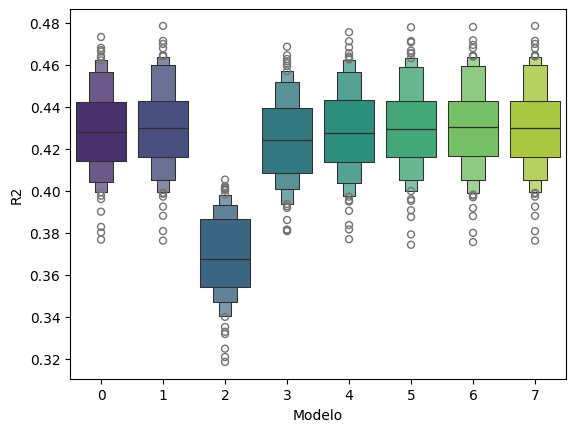

In [141]:
# Boxplot paralelo para comparar
sns.boxenplot(x='Modelo',y='R2',data=results,palette='viridis')


En este punto hay que decidir un modelo final.

Todo indica que el mejor modelo en todos los sentidos es el modelo final backward sin interacción. Modelo sencillo y con capacidad predictiva mayor en términos generales que sus competidores que además son más complejos. Claramente nos quedamos con el indicado como 1 que es el modelo de fórmula form2.

# Ajuste del modelo final. Interpretación de parámetros

Una vez escogido el modelo final. Hay que interpretar sus parámetros teniendo en cuenta que la estimación más robusta de los mismos será la que se obtiene utilizando el dataset completo y no solamente las instancias del conjunto de training.

De esta forma, se ajusta el modelo final a los datos completos.


In [143]:
# Ajusto regresión sin prop_missings
modelo_final = ols(form7,data=vinosCompra).fit()
print(modelo_final.summary())


                            OLS Regression Results                            
Dep. Variable:              Beneficio   R-squared:                       0.434
Model:                            OLS   Adj. R-squared:                  0.433
Method:                 Least Squares   F-statistic:                     348.2
Date:                Thu, 15 Jan 2026   Prob (F-statistic):               0.00
Time:                        15:12:53   Log-Likelihood:                -32697.
No. Observations:                4998   AIC:                         6.542e+04
Df Residuals:                    4986   BIC:                         6.550e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept               238.12

Conclusiones que podemos sacar para aquellos vinos con Compra = 1, es decir beneficio distinto de 0:

1)  Los vinos con **Clasificación 4 estrellas** tienen un beneficio estimado medio **209.464** unidades superior* a los vinos de clasificación Desconocida. El rango de variación esperado es [185.988, 232.940].

2)  El beneficio estimado medio de los vinos de **Clasificación 1 estrella** es **21.28** unidades superior* al de los vinos con Clasificación Deconocida. El rango de variación esperado es [5.392	37.186].

3)  El beneficio estimado medio de los vinos de **Etiqueta MB**, es **494.418** unidades mayor que el de los vinos con etiqueta MM. El rango de variación esperado es [459.772, 529.066].

4)  El aumento unitario de la **Calificación del Productor**, produce una *disminución* del beneficio estimado del vino de **8.54** unidades. Puede resultar sorprendente pero hay que tener en cuenta que la variación es a un nivel marginal, con lo cual se valora qué pasa con el aumento unitario de la calificación del propio productor para vinos con la misma clasificación, etiqueta y niveles de alcohol y acidez.

5)  El aumento unitario en el nivel de **Acidez** produce una disminución del Beneficio esperado de **7.44** unidades.

6)  El aumento unitario en el nivel de **Alcohol** produce un aumento del Beneficio esperado de **3.78** unidades.

Todas estas afirmaciones se hacen a constancia de todas las demás variables involucradas en el modelo (ceteris paribus), es decir, se valora el cambio marginal que tiene cada variable para valores fijos de todas las demás.

Así, ese aumento en los vinos de 4 * se da en aquellos que tienen la misma etiqueta, misma calificación del productor y mismos niveles de acidez y alcohol.



# Anexo: Posibilidades estadísticas para evaluación de relaciones

En este anexo se presentan distintos test estadísticos para poder evaluar la asociación significativa entre pares de variables.


## Caso categórica-categórica. Chi cuadrado

Se presenta la filosofía del test de la Chi cuadrado para tablas de contingencia que evalua la asociación entre las casillas de una tabla, es decir, si existe patrón de asociación en las probabilidades conjuntas con respecto a la hipótesis nula de independencia de soucesos (intersección nula y por tanto probabilidad condicionada igual al producto de probabilidades marginales y esas cosas)

**Entendiendo el test Chi-cuadrado**

Vamos a realizar un análisis de asociación de una tabla de contingencia basada en Chi-cuadrado. Para ilustrar esto, nos permitimos el lujo de adelantar algo que observaremos posteriormente y que podría afectar a nuestro modelo por la presencia de interacción entre las variables más relevantes *Clasificación* y *Etiqueta*.


In [ ]:
# Opción para calcular las medias de Beneficio en los cruces de Clasificación y etiqueta
print(pd.pivot_table(vinosCompra,index =['Etiqueta'],columns=['Clasificacion'],values=['Beneficio'],aggfunc=[np.mean]))

# Tabla de contingencia con la cuenta de frecuencia de observaciones en cada cruce
pd.crosstab(vinosCompra.Etiqueta,vinosCompra.Clasificacion)


Vayamos un poco más allá por un momento y nos planteamos si habrá un efecto de interacción entre estas dos variable relevantes. Que demonios queremos decir con esto? Si hay interacción, es posible que el efecto conjunto de las dos variable sobre la respuesta no sea uniforme o bien no sea el resultado de la adición simple de ambos efectos. De esta forma, nos planteamos si es igualmente probable encontrar un vino con Clasificación máxima y la peor Etiqueta, que un vino con Clasificación máxima y la mejor de las Etiquetas... La lógica puede inducir a pensar que debería existir cierto patrón de asociación..



In [ ]:
pd.crosstab(vinosCompra.Etiqueta,vinosCompra.Clasificacion)

In [ ]:
# Probamos el test chi cuadrado para ver las salidas
stats.chi2_contingency(pd.crosstab(vinosCompra.Etiqueta,vinosCompra.Clasificacion).values)

#pd.crosstab(data_trans.Beneficio_cut,vinosCompra.Clasificacion,margins=True,normalize='columns')


-   Primer valor: Valor del estadístico Chi-cuadrado
-   Segundo valor: p-valor del contraste de hipótesis (recordemos H0: no existe asociación)
-   Tercer valor: Grados de libertad de la distribución de contraste (filas-1)\*(columnas-1)
-   Cuarto valor: Matriz de valores esperados bajo H0 (según las distribuciones marginales de las variables, cuan probable es encontrar casilla 1,1... p(x=1)\*p(y=1)

El valor de chi es muy alto, por lo que el p-valor es muy pequeño, prácticamente 0. Por lo que se evidencia una asociación significativa entre estas dos variables, o bien, la matriz de valores observados es significativamente distinta a la matriz de valores esperados bajo independencia.

**Precaución!!** Hay una cosa importante en el test Chi-cuadrado. Los resultados no son robustos si alguna de las casillas tiene frecuencia esperada menor que 5. Si se da este caso, sería necesario recodificar alguna de las variables del cruce para obtener tamaño muestral suficiente en las marginales. En nuestro caso, esto no llega a suceder (ver matriz de frecuencias esperadas), sin embargo tenemos una casilla con frecuencia observada 0, lo cual puede estar tirando mucho del valor de la chi y de alguna forma distorsionando sus resultados. Por ello, no es mala práctica unir alguna categoría para evitar esto.


## Caso categorica-numérica mediante ANOVA

Los contrastes estadísticos pueden resultar de utilidad para contastar la significación de las relaciones visualizadas a nivel gráfico. De esta forma, si tenemos una factor y queremos cuantificar esta significación con respecto a la variable objetivo continua, no es descabellado pensar en un análisis de la varianza con un factor para valorar si las distribuciones en los subgrupos difieren de la distribución global.

El Anova realiza la descomposición de la *suma de cuadrados* en las componentes *explicada* y *residual*, de tal forma que imputamos una parte de la variabilidad de la variable continua al cambio en los niveles del factor y la parte que no se puede explicar solamente por ese cambio, queda como variabilidad no explicada. La idea es que la variabilidad explicada sea mucho mayor que la residual.

Para la variable *Región*: Se observa que el p-valor es superior a 0,05 por lo que la asociación no es significativa al 95% de nivel de confianza. Esta variable no influye mucho en el Beneficio.


In [ ]:
# get ANOVA table as R like output
import statsmodels.api as sm
from statsmodels.formula.api import ols

# ANOVA región
model = ols('Beneficio ~ C(Region)', data=vinosCompra).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table


Para la variable *Etiqueta*: Se observa que el p-valor es 0 por lo que la asociación es significativa a cualquier nivel de confianza. Esta variable influye mucho en el Beneficio.



In [ ]:
# ANOVA Etiqueta
model = ols('Beneficio ~ C(Etiqueta)', data=vinosCompra).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table


**ANOVA de doble vía**. Puede resultar útil para la evaluación de efectos conjuntos de factores sobre la objetivo continua. En este caso, evaluamos la interacción de la que ya sospechábamos entre *Clasificación* y *Etiqueta*.



In [ ]:
# ANOVA con dos factores e interacción
model = ols('Beneficio ~ C(Etiqueta) + C(Clasificacion) + C(Etiqueta):C(Clasificacion)', data=vinosCompra).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table


Se constata la significación estadística de todos los efectos presentes en el modelo. Podríamos decir que existe influencia marginal de ambos factores sobre el Beneficio pero también una influencia conjunta de ambos! Así, el beneficio esperado puede depender de la combinación de Clasificación y Etiqueta del vino.

Para ilustrar este efecto, podemos recurrir al gráfico de interacciones entre dos factores y la variable continua. Aquí, detalle de programación y es que no acepta el tipo *category* (con su orden) por lo que habrá que convertir las columnas en tipo 'object' (pero solo para esto!)


In [ ]:
from statsmodels.graphics.factorplots import interaction_plot
import matplotlib.pyplot as plt


# Gráfico de interacción de las componentes del ANOVA
fig = interaction_plot(x=vinosCompra.Etiqueta.astype('object'), trace=vinosCompra['Clasificacion'].astype('object'), response=vinosCompra['Beneficio'])
plt.show()


Se evidencia interacción entre los factores cuando las líneas se cortan en algún punto. Esto quier decir que la evolución del Beneficio a lo largo de las Etiquetas no se produce de la misma forma en todas los niveles de Clasificación.

Se puede observar esa falta de dato en la combinación MM - \*\*\*\*

Vamos a hacer la prueba de recategorizar alguno de los niveles implicados. Para decidir cual de ellos, recurriremos a 1) frecuencia de la categoría (reporte) y 2) Similitud con la categoría adyacente (boxplot-violin). De esta forma decidimos que parece más conveniente unir Etiqueta en sus categorías M y MM.


In [ ]:
# Unimos la categoría minoritaria MM con M en Etiqueta
vinosCompra['Etiqueta_r'] = vinosCompra.Etiqueta.replace(['M','MM'],'M-MM',inplace=False)


In [ ]:
pd.crosstab(vinosCompra.Etiqueta_r,vinosCompra.Clasificacion)



In [ ]:
# Probamos el test chi cuadrado para ver las salidas
stats.chi2_contingency(pd.crosstab(vinosCompra.Etiqueta_r,vinosCompra.Clasificacion).values)


In [ ]:
# Gráfico de interacción de las componentes del ANOVA
fig = interaction_plot(x=vinosCompra.Etiqueta_r.astype('object'), trace=vinosCompra['Clasificacion'].astype('object'), response=vinosCompra['Beneficio'])
plt.show()



Sigue evidenciándose interacción entre los factores, especialmente en la categoría desconocido.


# Probando algoritmos modernos

En esta sección nos planteamos si los modelos modernos serían capaces de mejorar el mediocre resultado en la regresión que proporciona nuestra querida regresión lineal. Para ello, vamos a introducir el uso de **pycaret**, librería de ML muy buena que viene de R y nos permite con muy poco código crear nuestro benchmark de modelización con muchos modelos distintos par aunos mismos datos. Así mismo, permite muchas opciones sobre pre procesos para variables y todo tipo de gestiones de cara a la modelización.

https://pycaret.org/

https://github.com/pycaret/pycaret/blob/master/tutorials/Tutorial%20-%20Regression.ipynb

https://anderfernandez.com/blog/pycaret-low-code-machine-learning-en-python/
    


In [ ]:
# pip install pycaret
# conda install pycaret
from pycaret.regression import *

define_setup = setup(
    data = vinosDep.drop('Compra',axis=1),
    target = 'Beneficio',
    #normalize = True,
    transformation = True,
    #remove_multicollinearity = True,
    #multicollinearity_threshold = 0.8,
    #feature_selection = True,
    #ignore_low_variance = True,
    #remove_outliers = True,
    #imputation_type = 'simple',
    #numeric_imputation = 'median'
)

In [ ]:
best_model = compare_models()

In [ ]:
print(best_model)

Los modelos modernos no tienen una capacidad sensíblemente superior a nuestra querida regresión lineal clásica... Pensamos entonces que estamos ante un problema de predicción difícil de modelizar, quizá por falta de variables... En este punto, nos planteamos el objetivo del problema y la recogida de los datos y seguramente nos toca comentar con la gente de los datos y el negocio a ver que puede estar pasando para que no haya forma de modelizar con cierta fiabilidad.